In [1]:
import micropip
await micropip.install("openpyxl")

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar
from IPython.display import display


# -----------------------------
# FILE AND MODEL CONFIGURATION
# -----------------------------

FILE = Path("Misc.xlsx")
SHEET_NAME = 0  # first sheet in the workbook

TRAIN_END = pd.Timestamp("2025-01-13")

CAPACITY_KBBL = 78500.0
ENTRY_Z = 1.0

# One NYMEX WTI contract represents 1,000 barrels
CONTRACT_SIZE_BBL = 1000.0

# Set above zero later for transaction-cost testing.
# This is charged whenever position changes by one unit.
COST_PER_POSITION_CHANGE = 0.0


# Your screenshot shows Friday inventory dates, which appear to be
# EIA week-ending dates rather than publication dates.
INVENTORY_DATES_ARE_RELEASE_DATES = False

# Use this only when you know an exact EIA release date differed
# from the automatic holiday-adjusted estimate.
#
# Example:
# RELEASE_DATE_OVERRIDES = {
#     "2025-01-17": "2025-01-23"
# }
RELEASE_DATE_OVERRIDES = {}


if not FILE.exists():
    raise FileNotFoundError(
        f"Could not find {FILE.resolve()}. "
        "Make sure misc.xlsx is in the same folder as the notebook."
    )

print(f"Using file: {FILE.resolve()}")

Using file: /drive/notebooks/Misc.xlsx


In [3]:
# Read columns A:G, regardless of their Excel header names
raw = pd.read_excel(
    FILE,
    sheet_name=SHEET_NAME,
    usecols="A:G"
)

if raw.shape[1] < 7:
    raise ValueError(
        "The workbook must contain data in columns A:G."
    )

raw = raw.iloc[:, :7].copy()

raw.columns = [
    "cl1_date",
    "cl1",
    "cl2_date",
    "cl2",
    "spread_excel",
    "inventory_date",
    "inventory"
]


# -----------------------------
# CLEAN CL1
# -----------------------------

cl1 = raw[["cl1_date", "cl1"]].copy()
cl1["date"] = pd.to_datetime(cl1["cl1_date"], errors="coerce")
cl1["cl1"] = pd.to_numeric(cl1["cl1"], errors="coerce")

cl1 = (
    cl1[["date", "cl1"]]
    .dropna()
    .drop_duplicates(subset="date", keep="last")
    .sort_values("date")
)


# -----------------------------
# CLEAN CL2
# -----------------------------

cl2 = raw[["cl2_date", "cl2"]].copy()
cl2["date"] = pd.to_datetime(cl2["cl2_date"], errors="coerce")
cl2["cl2"] = pd.to_numeric(cl2["cl2"], errors="coerce")

cl2 = (
    cl2[["date", "cl2"]]
    .dropna()
    .drop_duplicates(subset="date", keep="last")
    .sort_values("date")
)


# Inner join so every row has both CL1 and CL2
prices = cl1.merge(
    cl2,
    on="date",
    how="inner",
    validate="one_to_one"
)

prices["spread"] = prices["cl1"] - prices["cl2"]

prices = (
    prices
    .sort_values("date")
    .reset_index(drop=True)
)


# -----------------------------
# CLEAN WEEKLY INVENTORY DATA
# -----------------------------

inventory = raw[["inventory_date", "inventory"]].copy()

inventory["inventory_date"] = pd.to_datetime(
    inventory["inventory_date"],
    errors="coerce"
)

inventory["inventory"] = pd.to_numeric(
    inventory["inventory"],
    errors="coerce"
)

inventory = (
    inventory
    .dropna()
    .drop_duplicates(subset="inventory_date", keep="last")
    .sort_values("inventory_date")
    .reset_index(drop=True)
)


# -----------------------------
# DETERMINE WHEN INVENTORY
# BECAME AVAILABLE TO THE MARKET
# -----------------------------

if INVENTORY_DATES_ARE_RELEASE_DATES:
    inventory["release_date"] = inventory["inventory_date"]

else:
    # A Friday week-ending observation is ordinarily released
    # three US business days later, on Wednesday.
    us_business_day = CustomBusinessDay(
        calendar=USFederalHolidayCalendar()
    )

    inventory["release_date"] = inventory["inventory_date"].map(
        lambda date: date + 3 * us_business_day
    )


# Apply manual release-date corrections, if supplied
for inventory_date, release_date in RELEASE_DATE_OVERRIDES.items():
    inventory_date = pd.Timestamp(inventory_date)
    release_date = pd.Timestamp(release_date)

    inventory.loc[
        inventory["inventory_date"] == inventory_date,
        "release_date"
    ] = release_date


inventory = (
    inventory
    .sort_values("release_date")
    .drop_duplicates(subset="release_date", keep="last")
    .reset_index(drop=True)
)


# -----------------------------
# AS-OF JOIN WITH NO LOOKAHEAD
# -----------------------------

df = pd.merge_asof(
    prices.sort_values("date"),
    inventory[
        ["inventory_date", "release_date", "inventory"]
    ].sort_values("release_date"),
    left_on="date",
    right_on="release_date",
    direction="backward",
    allow_exact_matches=True
)

df["utilization"] = df["inventory"] / CAPACITY_KBBL

# Remove impossible utilization values from model calculations
df.loc[
    ~df["utilization"].between(0.01, 0.99),
    "utilization"
] = np.nan

df = df.reset_index(drop=True)

print(f"Price observations: {len(df):,}")
print(f"First price date:    {df['date'].min():%Y-%m-%d}")
print(f"Last price date:     {df['date'].max():%Y-%m-%d}")
print(f"Training cutoff:     {TRAIN_END:%Y-%m-%d}")

display(
    df[
        [
            "date",
            "cl1",
            "cl2",
            "spread",
            "inventory_date",
            "release_date",
            "inventory",
            "utilization"
        ]
    ].tail(15)
)

Price observations: 2,650
First price date:    2016-01-04
Last price date:     2026-07-13
Training cutoff:     2025-01-13


,date,cl1,cl2,spread,inventory_date,release_date,inventory,utilization
2635,2026-06-22,74.82,73.86,0.96,2026-06-12,2026-06-17,20034.0,0.255210
2636,2026-06-23,73.21,72.54,0.67,2026-06-12,2026-06-17,20034.0,0.255210
2637,2026-06-24,70.34,69.93,0.41,2026-06-19,2026-06-24,18957.0,0.241490
2638,2026-06-25,71.92,71.52,0.40,2026-06-19,2026-06-24,18957.0,0.241490
2639,2026-06-26,69.23,68.93,0.30,2026-06-19,2026-06-24,18957.0,0.241490
2640,2026-06-29,70.75,70.41,0.34,2026-06-19,2026-06-24,18957.0,0.241490
2641,2026-06-30,69.50,69.27,0.23,2026-06-19,2026-06-24,18957.0,0.241490
2642,2026-07-01,68.58,68.51,0.07,2026-06-26,2026-07-01,19666.0,0.250522
2643,2026-07-02,68.69,68.65,0.04,2026-06-26,2026-07-01,19666.0,0.250522
2644,2026-07-06,68.55,68.56,-0.01,2026-06-26,2026-07-01,19666.0,0.250522


In [4]:
# Training data ends on January 13, 2025
train_mask = (
    (df["date"] <= TRAIN_END)
    & df["spread"].notna()
    & df["utilization"].notna()
)

train = df.loc[train_mask].copy()

if len(train) < 30:
    raise ValueError(
        "Too few valid training observations. "
        "Check the date and inventory columns."
    )


u_train = train["utilization"].to_numpy()
y_train = train["spread"].to_numpy()

X_train = np.column_stack(
    [
        np.ones(len(train)),
        1 / u_train,
        1 / (1 - u_train)
    ]
)

beta, residual_sum_squares, rank, singular_values = np.linalg.lstsq(
    X_train,
    y_train,
    rcond=None
)

beta_0, beta_low_inventory, beta_full_storage = beta


# Calculate fair value across the full dataset
valid_u = df["utilization"].notna()

df["fair_value"] = np.nan

u_all = df.loc[valid_u, "utilization"]

df.loc[valid_u, "fair_value"] = (
    beta_0
    + beta_low_inventory / u_all
    + beta_full_storage / (1 - u_all)
)

df["residual"] = df["spread"] - df["fair_value"]


# Residual standard deviation is frozen using training data only
training_residuals = df.loc[train_mask, "residual"]

RESIDUAL_SIGMA = training_residuals.std(ddof=1)

df["zscore"] = df["residual"] / RESIDUAL_SIGMA


model_parameters = pd.DataFrame(
    {
        "Parameter": [
            "Intercept",
            "1 / utilization coefficient",
            "1 / spare-capacity coefficient",
            "Training residual standard deviation",
            "Training observations"
        ],
        "Value": [
            beta_0,
            beta_low_inventory,
            beta_full_storage,
            RESIDUAL_SIGMA,
            len(train)
        ]
    }
)

display(model_parameters)

print(
    "\nFair-value equation:\n"
    f"Spread = {beta_0:.6f}"
    f" + ({beta_low_inventory:.6f} / utilization)"
    f" + ({beta_full_storage:.6f} / (1 - utilization))"
)

,Parameter,Value
0,Intercept,-1.542135
1,1 / utilization coefficient,0.795252
2,1 / spare-capacity coefficient,-0.028715
3,Training residual standard deviation,1.405644
4,Training observations,2273.000000



Fair-value equation:
Spread = -1.542135 + (0.795252 / utilization) + (-0.028715 / (1 - utilization))


In [5]:
n = len(df)

position = np.zeros(n, dtype=int)


for i in range(1, n):

    date = df.at[i, "date"]
    zscore = df.at[i, "zscore"]
    residual = df.at[i, "residual"]

    # No backtest position during training period
    if date <= TRAIN_END:
        position[i] = 0
        continue

    if not np.isfinite(zscore) or not np.isfinite(residual):
        position[i] = 0
        continue

    previous_position = position[i - 1]

    # Flat: check for a new entry
    if previous_position == 0:

        if zscore <= -ENTRY_Z:
            # Actual spread is materially below fair value
            position[i] = 1

        elif zscore >= ENTRY_Z:
            # Actual spread is materially above fair value
            position[i] = -1

        else:
            position[i] = 0

    # Currently long the spread
    elif previous_position == 1:

        if residual >= 0:
            position[i] = 0
        else:
            position[i] = 1

    # Currently short the spread
    elif previous_position == -1:

        if residual <= 0:
            position[i] = 0
        else:
            position[i] = -1


df["position"] = position

# Position held over the previous close-to-close interval
df["previous_position"] = df["position"].shift(1).fillna(0)

df["spread_change"] = df["spread"].diff()

df["gross_pnl"] = (
    df["previous_position"]
    * df["spread_change"]
    * CONTRACT_SIZE_BBL
)

# Entry or exit turnover
df["position_change"] = (
    df["position"] - df["previous_position"]
).abs()

df["transaction_cost"] = (
    df["position_change"]
    * COST_PER_POSITION_CHANGE
)

df["daily_pnl"] = (
    df["gross_pnl"]
    - df["transaction_cost"]
)

# Eliminate accidental pre-test P&L
df.loc[df["date"] <= TRAIN_END, "daily_pnl"] = 0.0

df["daily_pnl"] = df["daily_pnl"].fillna(0.0)
df["cumulative_pnl"] = df["daily_pnl"].cumsum()

df["equity_peak"] = df["cumulative_pnl"].cummax()
df["drawdown"] = (
    df["cumulative_pnl"]
    - df["equity_peak"]
)


# -----------------------------
# LABEL ENTRY AND EXIT DAYS
# -----------------------------

df["action"] = ""

df.loc[
    (df["previous_position"] == 0)
    & (df["position"] == 1),
    "action"
] = "ENTER LONG"

df.loc[
    (df["previous_position"] == 0)
    & (df["position"] == -1),
    "action"
] = "ENTER SHORT"

df.loc[
    (df["previous_position"] == 1)
    & (df["position"] == 0),
    "action"
] = "EXIT LONG"

df.loc[
    (df["previous_position"] == -1)
    & (df["position"] == 0),
    "action"
] = "EXIT SHORT"


display(
    df.loc[
        df["date"] > TRAIN_END,
        [
            "date",
            "spread",
            "fair_value",
            "residual",
            "zscore",
            "position",
            "action",
            "daily_pnl",
            "cumulative_pnl"
        ]
    ].tail(20)
)

,date,spread,fair_value,residual,zscore,position,action,daily_pnl,cumulative_pnl
2630,2026-06-12,1.53,1.303030,0.226970,0.161470,-1,,20.0,2920.0
2631,2026-06-15,1.31,1.303030,0.006970,0.004958,-1,,220.0,3140.0
2632,2026-06-16,0.78,1.303030,-0.523030,-0.372093,0,EXIT SHORT,530.0,3670.0
2633,2026-06-17,0.78,1.535376,-0.755376,-0.537388,0,,0.0,3670.0
2634,2026-06-18,0.75,1.535376,-0.785376,-0.558730,0,,-0.0,3670.0
2635,2026-06-22,0.96,1.535376,-0.575376,-0.409333,0,,0.0,3670.0
2636,2026-06-23,0.67,1.535376,-0.865376,-0.615644,0,,-0.0,3670.0
2637,2026-06-24,0.41,1.713106,-1.303106,-0.927052,0,,-0.0,3670.0
2638,2026-06-25,0.40,1.713106,-1.313106,-0.934167,0,,-0.0,3670.0
2639,2026-06-26,0.30,1.713106,-1.413106,-1.005308,1,ENTER LONG,-0.0,3670.0


In [6]:
trades = []
open_trade = None


for i, row in df.iterrows():

    action = row["action"]

    if action in ("ENTER LONG", "ENTER SHORT"):

        open_trade = {
            "entry_index": i,
            "entry_date": row["date"],
            "direction": "LONG" if row["position"] == 1 else "SHORT",
            "entry_spread": row["spread"],
            "entry_fair_value": row["fair_value"],
            "entry_zscore": row["zscore"]
        }

    elif action in ("EXIT LONG", "EXIT SHORT") and open_trade is not None:

        entry_index = open_trade["entry_index"]

        trade_pnl = df.loc[
            entry_index:i,
            "daily_pnl"
        ].sum()

        trades.append(
            {
                **open_trade,
                "exit_index": i,
                "exit_date": row["date"],
                "exit_spread": row["spread"],
                "exit_fair_value": row["fair_value"],
                "exit_zscore": row["zscore"],
                "holding_days": i - entry_index,
                "trade_pnl": trade_pnl,
                "status": "CLOSED"
            }
        )

        open_trade = None


# Include an open position at the end of the dataset
if open_trade is not None:

    i = df.index[-1]
    row = df.iloc[-1]
    entry_index = open_trade["entry_index"]

    trade_pnl = df.loc[
        entry_index:i,
        "daily_pnl"
    ].sum()

    trades.append(
        {
            **open_trade,
            "exit_index": np.nan,
            "exit_date": pd.NaT,
            "exit_spread": np.nan,
            "exit_fair_value": np.nan,
            "exit_zscore": np.nan,
            "holding_days": i - entry_index,
            "trade_pnl": trade_pnl,
            "status": "OPEN"
        }
    )


trades = pd.DataFrame(trades)

if trades.empty:
    print("No trades were generated.")
else:
    display(
        trades[
            [
                "entry_date",
                "exit_date",
                "direction",
                "entry_spread",
                "exit_spread",
                "entry_zscore",
                "exit_zscore",
                "holding_days",
                "trade_pnl",
                "status"
            ]
        ]
    )

,entry_date,exit_date,direction,entry_spread,exit_spread,entry_zscore,exit_zscore,holding_days,trade_pnl,status
0,2026-03-05,2026-03-17,SHORT,2.37,0.68,1.135717,-0.059122,8,1690.0,CLOSED
1,2026-03-23,2026-06-16,SHORT,2.76,0.78,1.478505,-0.372093,60,1980.0,CLOSED
2,2026-06-26,NaT,LONG,0.30,NaN,-1.005308,NaN,10,-200.0,OPEN


In [7]:
oos = df.loc[df["date"] > TRAIN_END].copy()

closed_trades = (
    trades.loc[trades["status"] == "CLOSED"].copy()
    if not trades.empty
    else pd.DataFrame()
)

total_pnl = oos["daily_pnl"].sum()
max_drawdown = oos["drawdown"].min()

daily_pnl_std = oos["daily_pnl"].std(ddof=1)

if daily_pnl_std > 0:
    pnl_sharpe = (
        oos["daily_pnl"].mean()
        / daily_pnl_std
        * np.sqrt(252)
    )
else:
    pnl_sharpe = np.nan


if len(closed_trades) > 0:

    winning_trades = closed_trades["trade_pnl"] > 0
    losing_trades = closed_trades["trade_pnl"] < 0

    win_rate = winning_trades.mean()
    average_trade = closed_trades["trade_pnl"].mean()
    median_trade = closed_trades["trade_pnl"].median()

    gross_profit = closed_trades.loc[
        winning_trades,
        "trade_pnl"
    ].sum()

    gross_loss = abs(
        closed_trades.loc[
            losing_trades,
            "trade_pnl"
        ].sum()
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

else:
    win_rate = np.nan
    average_trade = np.nan
    median_trade = np.nan
    profit_factor = np.nan


summary = pd.DataFrame(
    {
        "Metric": [
            "Backtest start",
            "Backtest end",
            "Entry threshold",
            "Total P&L",
            "Maximum drawdown",
            "Annualized daily-P&L Sharpe",
            "Closed trades",
            "Win rate",
            "Average closed-trade P&L",
            "Median closed-trade P&L",
            "Profit factor",
            "Current position"
        ],
        "Value": [
            oos["date"].min(),
            oos["date"].max(),
            ENTRY_Z,
            total_pnl,
            max_drawdown,
            pnl_sharpe,
            len(closed_trades),
            win_rate,
            average_trade,
            median_trade,
            profit_factor,
            int(oos["position"].iloc[-1])
        ]
    }
)

display(summary)

,Metric,Value
0,Backtest start,2025-01-14 00:00:00
1,Backtest end,2026-07-13 00:00:00
2,Entry threshold,1.0
3,Total P&L,3470.0
4,Maximum drawdown,-11400.0
5,Annualized daily-P&L Sharpe,0.265149
6,Closed trades,2
7,Win rate,1.0
8,Average closed-trade P&L,1835.0
9,Median closed-trade P&L,1835.0


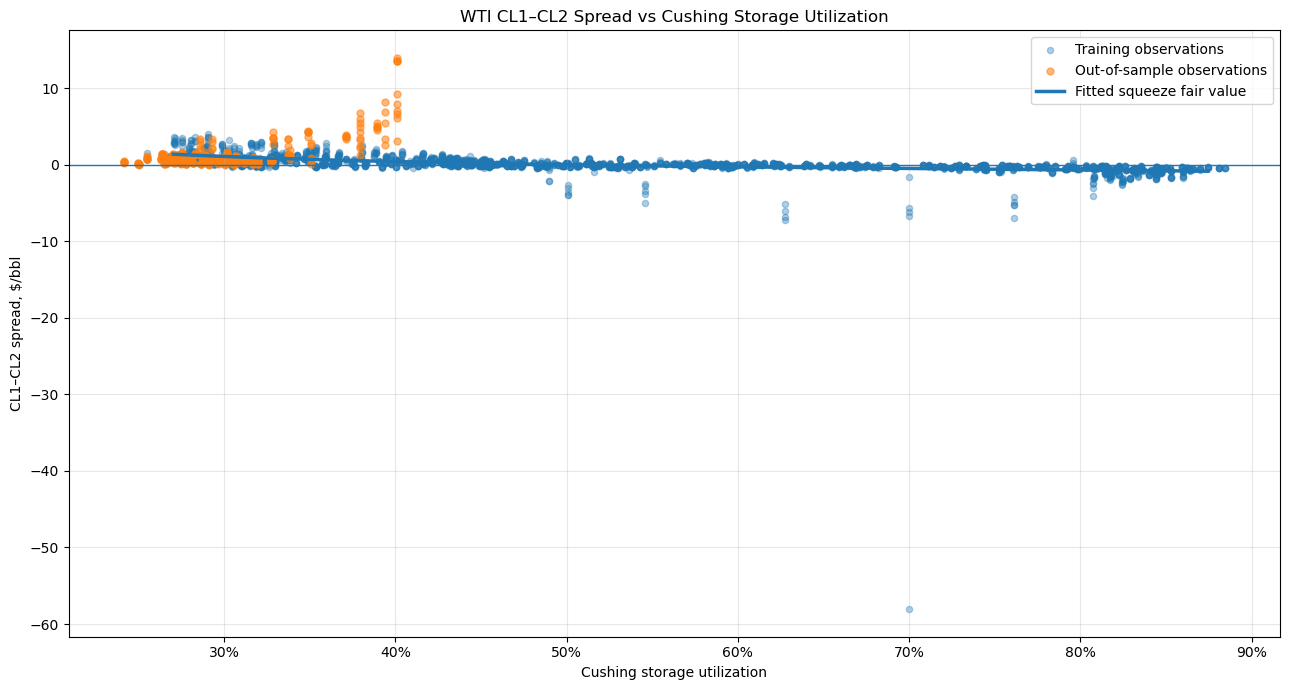

In [8]:
train_plot = df.loc[
    (df["date"] <= TRAIN_END)
    & df["utilization"].notna()
    & df["spread"].notna()
].copy()

test_plot = df.loc[
    (df["date"] > TRAIN_END)
    & df["utilization"].notna()
    & df["spread"].notna()
].copy()


u_min = train_plot["utilization"].quantile(0.005)
u_max = train_plot["utilization"].quantile(0.995)

u_grid = np.linspace(
    max(0.01, u_min),
    min(0.99, u_max),
    500
)

fair_value_grid = (
    beta_0
    + beta_low_inventory / u_grid
    + beta_full_storage / (1 - u_grid)
)


fig, ax = plt.subplots(figsize=(13, 7))

ax.scatter(
    train_plot["utilization"],
    train_plot["spread"],
    alpha=0.35,
    s=20,
    label="Training observations"
)

ax.scatter(
    test_plot["utilization"],
    test_plot["spread"],
    alpha=0.55,
    s=25,
    label="Out-of-sample observations"
)

ax.plot(
    u_grid,
    fair_value_grid,
    linewidth=2.5,
    label="Fitted squeeze fair value"
)

ax.set_title(
    "WTI CL1–CL2 Spread vs Cushing Storage Utilization"
)

ax.set_xlabel("Cushing storage utilization")
ax.set_ylabel("CL1–CL2 spread, $/bbl")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

ax.axhline(0, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

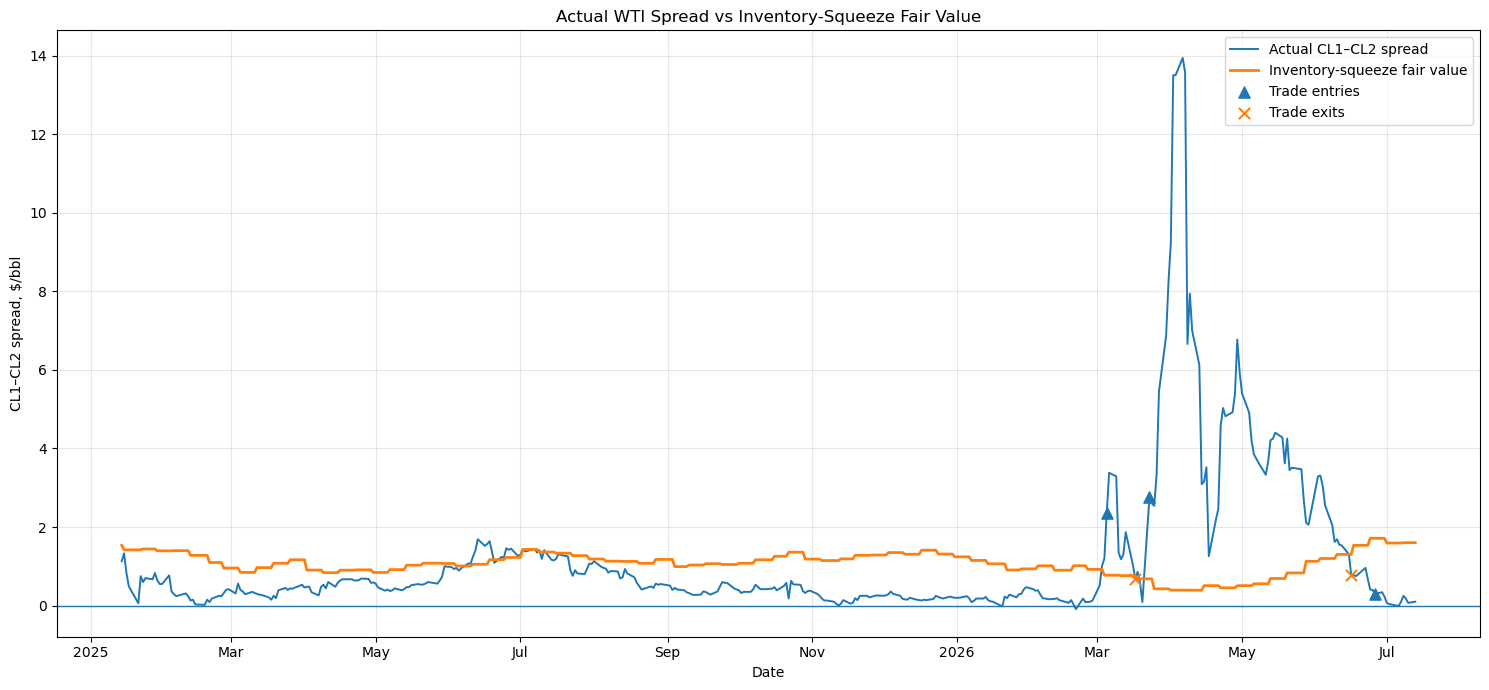

In [9]:
plot_df = df.loc[df["date"] > TRAIN_END].copy()

entries = plot_df[
    plot_df["action"].isin(["ENTER LONG", "ENTER SHORT"])
]

exits = plot_df[
    plot_df["action"].isin(["EXIT LONG", "EXIT SHORT"])
]


fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    plot_df["date"],
    plot_df["spread"],
    linewidth=1.4,
    label="Actual CL1–CL2 spread"
)

ax.plot(
    plot_df["date"],
    plot_df["fair_value"],
    linewidth=2,
    label="Inventory-squeeze fair value"
)

ax.scatter(
    entries["date"],
    entries["spread"],
    marker="^",
    s=65,
    label="Trade entries",
    zorder=3
)

ax.scatter(
    exits["date"],
    exits["spread"],
    marker="x",
    s=65,
    label="Trade exits",
    zorder=3
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Actual WTI Spread vs Inventory-Squeeze Fair Value"
)

ax.set_xlabel("Date")
ax.set_ylabel("CL1–CL2 spread, $/bbl")

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(locator)
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()